# Prediccio de la Corba de Temperatura (30 min) a partir de Dades Diaries

**Objectiu:** Donats els agregats diaries de temperatura i variables meteorologiques d'un dia, predir la corba de temperatura a resolucio 30 min (48 valors).

**Dos conjunts de dades:**
- **Comunes** (12 features, ambdues estacions, ~17k dies): T_avg, T_max, T_min, humitat, pluja, pressio, T_range, T_avg_lag1, sin/cos_doy, month, estacio
- **Completes** (15 features, Sbd Nord, ~6.3k dies): les anteriors + radiacio + vent

**Models:** Sinusoïdal (2-stage), KNN, Random Forest, XGBoost, MLP

## 1. Imports i Configuracio

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from scipy.optimize import curve_fit
from scipy.stats import norm

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost no instal·lat — s'ometra")

HOURS_PER_DAY = 48
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

XGBoost no instal·lat — s'ometra


## 2. Part A: Features Comunes (ambdues estacions)

### 2.1 Carrega de dades

In [2]:
data_c = np.load("Cleaned Data/ml_data_common.npz", allow_pickle=False)
meta_c = pd.read_csv("Cleaned Data/ml_metadata_common.csv")

X, y = data_c['X'], data_c['y']
feature_names = data_c['feature_names'].tolist()
target_names = data_c['target_names'].tolist()
years = data_c['years']
months = data_c['months']
station_ids = data_c['station_ids']
dates_str = meta_c['date'].values
stations_str = meta_c['station'].values
timestamps = pd.Series(pd.to_datetime(dates_str))

print(f"X: {X.shape}, y: {y.shape}")
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Date range: {timestamps.min().date()} a {timestamps.max().date()}")
print(f"Estacions: {meta_c['station'].value_counts().to_dict()}")

X: (17070, 12), y: (17070, 48)
Features (12): ['T_avg', 'T_max', 'T_min', 'humidity_avg', 'rain_mm', 'pressure_avg', 'T_range', 'T_avg_lag1', 'sin_doy', 'cos_doy', 'month', 'is_sbd']
Date range: 1996-02-17 a 2026-04-01
Estacions: {'Vacarisses': 10703, 'Sbd Nord': 6367}


### 2.2 Train/Test Split Temporal

In [3]:
train_mask = timestamps.dt.year <= 2020
test_mask = ~train_mask

X_tr, X_te = X[train_mask], X[test_mask]
y_tr, y_te = y[train_mask], y[test_mask]
dates_te = dates_str[test_mask]
stations_te = stations_str[test_mask]
months_te = months[test_mask]
ts_tr = timestamps[train_mask]
ts_te = timestamps[test_mask]

print(f"Train: {X_tr.shape[0]:,} dies ({ts_tr.min().date()} - {ts_tr.max().date()})")
print(f"Test:  {X_te.shape[0]:,} dies ({ts_te.min().date()} - {ts_te.max().date()})")

Train: 13,238 dies (1996-02-17 - 2020-12-31)
Test:  3,832 dies (2021-01-01 - 2026-04-01)


### 2.3 Visualitzacio exploratoria

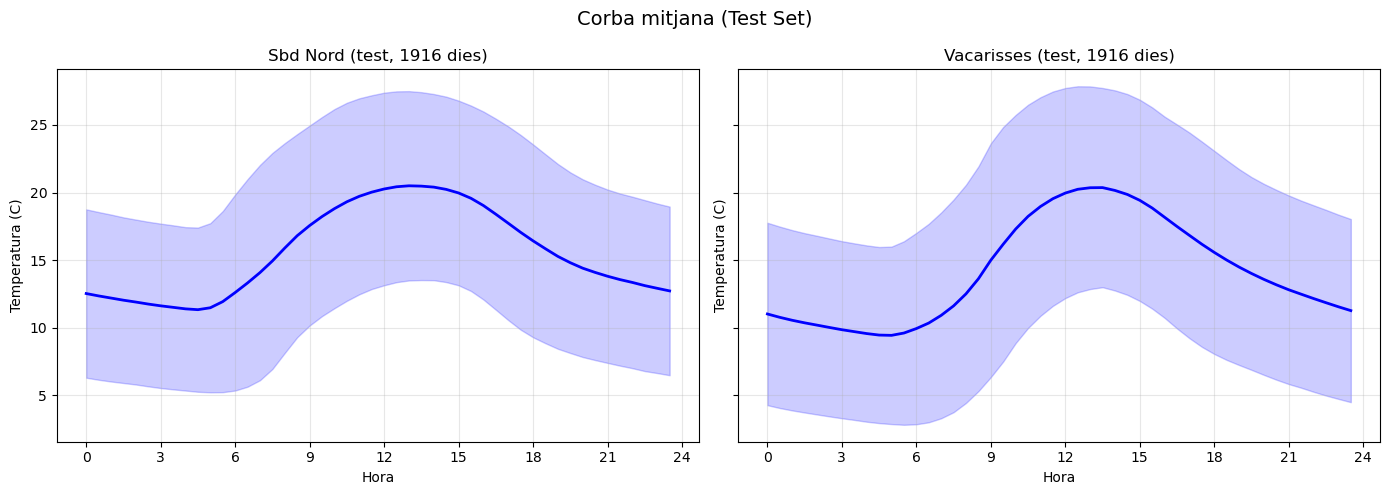

In [4]:
slots = np.arange(HOURS_PER_DAY)
hours = slots / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, name in zip(axes, ['Sbd Nord', 'Vacarisses']):
    mask = stations_te == name
    mu = y_te[mask].mean(0); sd = y_te[mask].std(0)
    ax.plot(hours, mu, 'b-', lw=2)
    ax.fill_between(hours, mu - sd, mu + sd, alpha=0.2, color='b')
    ax.set_title(f"{name} (test, {mask.sum()} dies)")
    ax.set_xlabel("Hora"); ax.set_ylabel("Temperatura (C)")
    ax.grid(alpha=0.3); ax.set_xticks(range(0, 25, 3))
fig.suptitle("Corba mitjana (Test Set)", fontsize=14); plt.tight_layout(); plt.show()

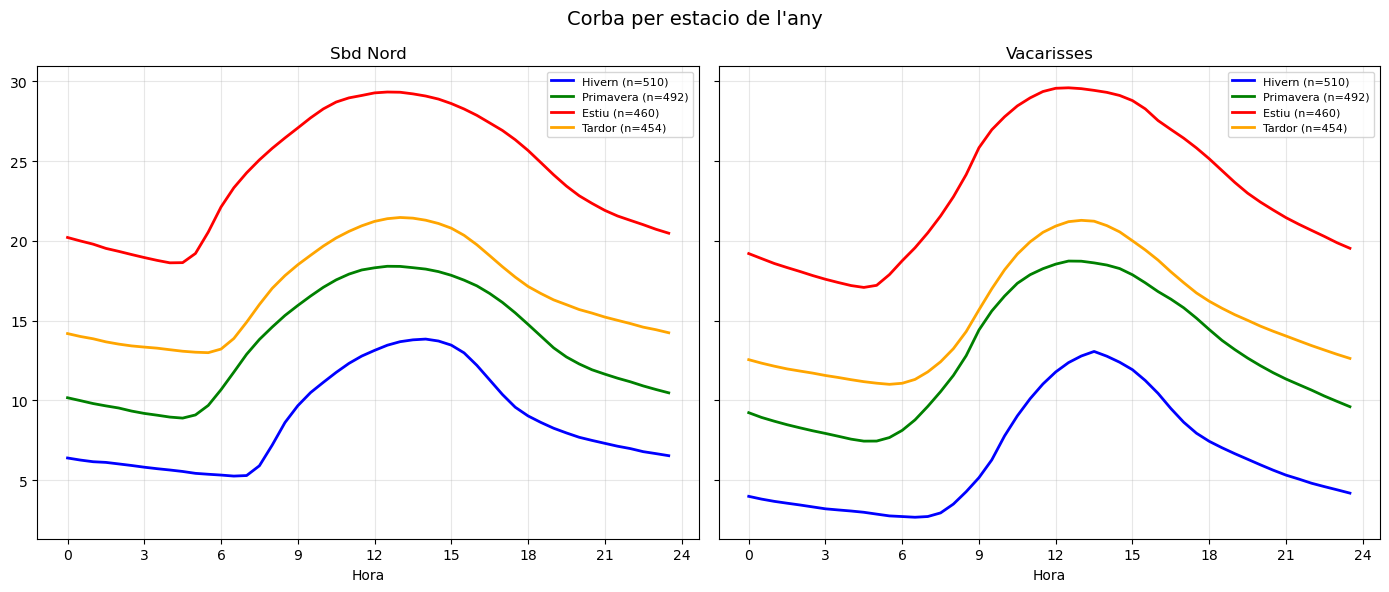

In [5]:
season_map = {'Hivern':[12,1,2],'Primavera':[3,4,5],'Estiu':[6,7,8],'Tardor':[9,10,11]}
cols_s = {'Hivern':'blue','Primavera':'green','Estiu':'red','Tardor':'orange'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, name in zip(axes, ['Sbd Nord', 'Vacarisses']):
    mask = stations_te == name
    for ssn, ms in season_map.items():
        sm = mask & np.isin(pd.to_datetime(dates_te).month, ms)
        if sm.sum() == 0: continue
        ax.plot(hours, y_te[sm].mean(0), label=f"{ssn} (n={sm.sum()})",
                color=cols_s[ssn], lw=2)
    ax.set_title(name); ax.set_xlabel("Hora"); ax.legend(fontsize=8)
    ax.grid(alpha=0.3); ax.set_xticks(range(0, 25, 3))
fig.suptitle("Corba per estacio de l'any", fontsize=14); plt.tight_layout(); plt.show()

### 2.4 Funcions d'avaluacio

In [6]:
def evaluate(name, yt, yp, verbose=True):
    rmses = np.sqrt(mean_squared_error(yt, yp, multioutput='raw_values'))
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2 = r2_score(yt, yp)
    bias = (yp - yt).mean()
    if verbose:
        print(f"{name}:")
        print(f"  RMSE: {rmse:.3f}C  R2: {r2:.4f}  Bias: {bias:.3f}C")
        print(f"  RMSE/slot: {rmses.mean():.3f} +/- {rmses.std():.3f}C")
    return {'name':name,'rmse_global':rmse,'rmse_mean':rmses.mean(),
            'rmse_std':rmses.std(),'r2':r2,'bias':bias,'rmse_per_slot':rmses}

def plot_curves(yt, yp, title, n=4, dates=None, stations=None):
    idx = np.random.choice(len(yt), n, replace=False)
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    h = np.arange(HOURS_PER_DAY) / 2
    for ax, i in zip(axes.flat, idx):
        ax.plot(h, yt[i], 'b-o', label='Real', ms=3, lw=1.5)
        ax.plot(h, yp[i], 'r--s', label='Pred', ms=3, lw=1.5)
        lbl = (f"{dates[i]} " if dates is not None else "") + (f"({stations[i]})" if stations is not None else "")
        ax.set_title(lbl); ax.set_xlabel("Hora"); ax.set_ylabel("Temperatura (C)")
        ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xticks(range(0, 25, 3))
    fig.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()

def plot_rmse_slot(results):
    fig, ax = plt.subplots(figsize=(12, 5))
    h = np.arange(HOURS_PER_DAY) / 2
    for r in results:
        ax.plot(h, r['rmse_per_slot'], label=f"{r['name']} ({r['rmse_global']:.3f}C)", lw=1.5)
    ax.set_xlabel("Hora"); ax.set_ylabel("RMSE (C)"); ax.set_title("RMSE per franja (30 min)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xticks(range(0, 25, 3))
    plt.tight_layout(); plt.show()

def results_table(results):
    print(f"{'Model':<20} {'RMSE (C)':<12} {'R2':<10} {'Bias (C)':<10}")
    print("-"*52)
    for r in results:
        print(f"{r['name']:<20} {r['rmse_global']:<12.3f} {r['r2']:<10.4f} {r['bias']:<10.3f}")

## 3. Model 1: Sinusoidal (Baseline fisic)
Ajustem una sinusoide a cada dia optimitzant amplitud `A` i fase `phi`:
$T(t) = T_{avg} + A \cdot \sin(\omega t + \phi)$

Aquest es un *oracle*: fa servir les dades reals del dia per ajustar
A i phi, donant el millor resultat possible amb una sinusoide.

Sinusoidal (oracle):
  RMSE: 1.468C  R2: 0.9571  Bias: -0.000C
  RMSE/slot: 1.444 +/- 0.263C


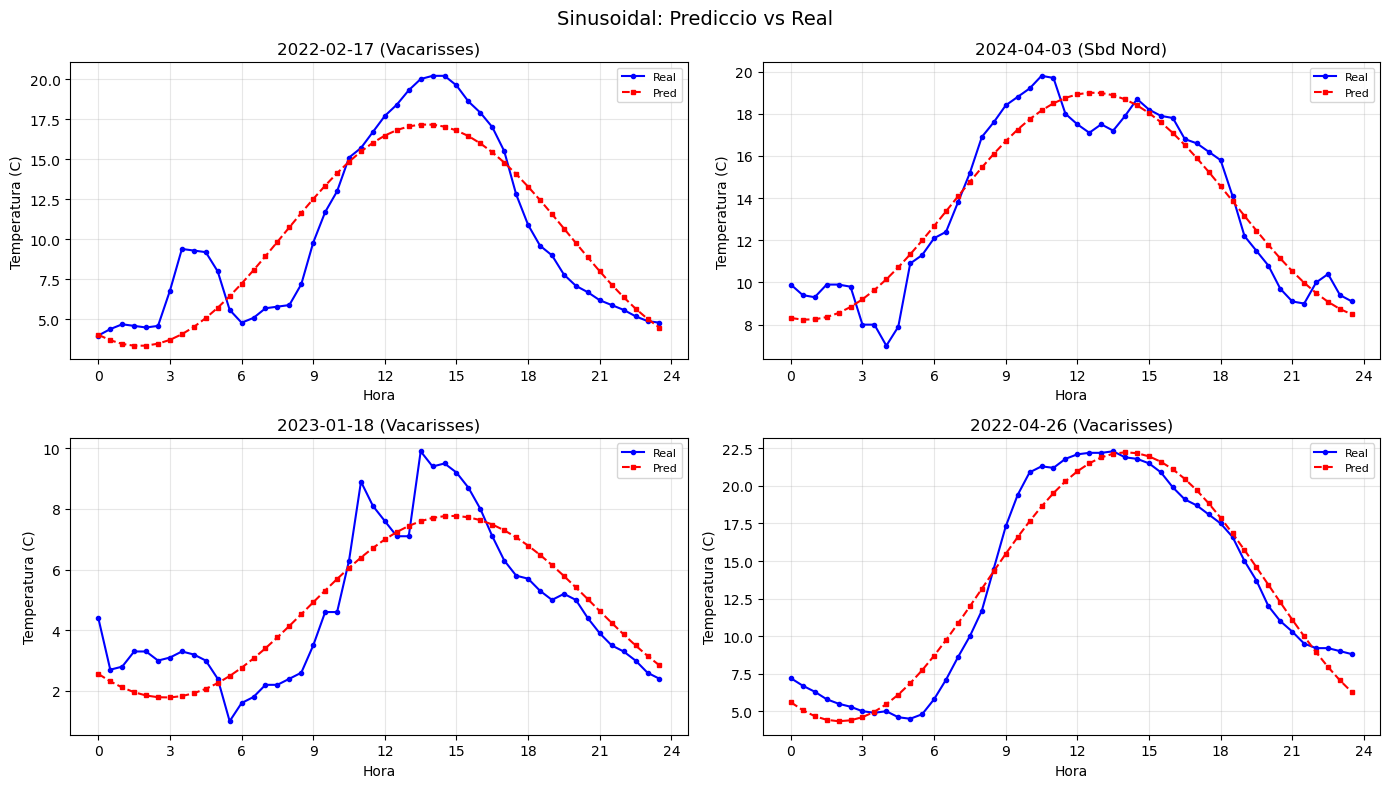

In [7]:
def fit_sin_per_day(y_data, T_avg_day):
    t = np.arange(HOURS_PER_DAY) / 2
    y_pred = np.zeros_like(y_data)
    for i in range(len(y_data)):
        A_init = max((y_data[i].max() - y_data[i].min()) / 2, 0.1)
        try:
            popt, _ = curve_fit(
                lambda x, A, phi: T_avg_day[i] + A * np.sin(2*np.pi*x/24 + phi),
                t, y_data[i], p0=[A_init, -np.pi/2 + 3.5], maxfev=5000)
            y_pred[i] = T_avg_day[i] + popt[0] * np.sin(2*np.pi*t/24 + popt[1])
        except:
            y_pred[i] = T_avg_day[i] + A_init * np.sin(2*np.pi*t/24 - np.pi/2 + 3.5)
    return y_pred

t = np.arange(HOURS_PER_DAY) / 2
T_avg_te = X_te[:, feature_names.index('T_avg')]
y_sin = fit_sin_per_day(y_te, T_avg_te)
res_sin = evaluate("Sinusoidal (oracle)", y_te, y_sin)
plot_curves(y_te, y_sin, "Sinusoidal: Prediccio vs Real",
            dates=dates_te, stations=stations_te)

## 4. Model 2: KNN

GridSearch KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best: {'knn__n_neighbors': 10, 'knn__p': 1, 'knn__weights': 'distance'}
KNN:
  RMSE: 1.454C  R2: 0.9569  Bias: -0.130C
  RMSE/slot: 1.443 +/- 0.181C


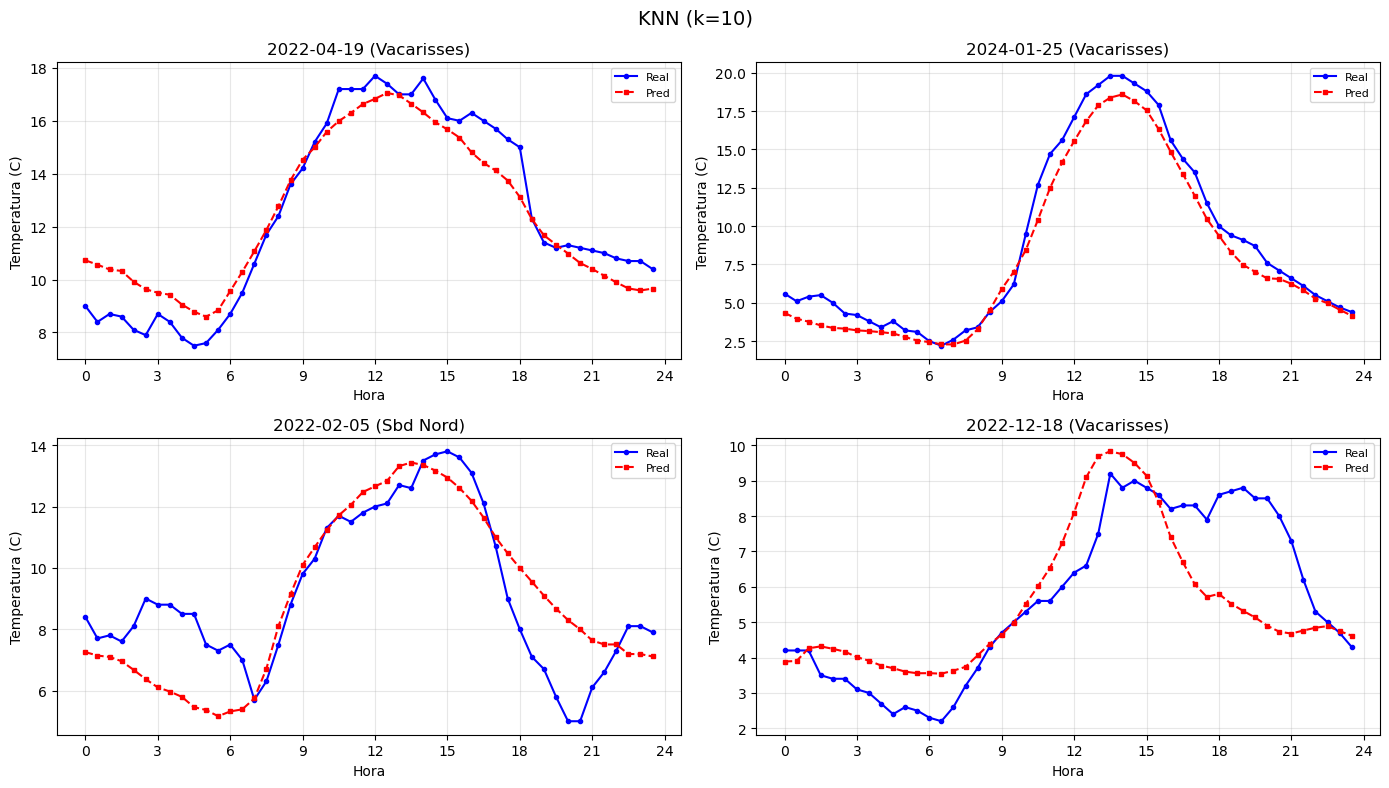

In [8]:
pipe_knn = Pipeline([('scaler',StandardScaler()),('knn',KNeighborsRegressor())])
params_knn = {'knn__n_neighbors':[5,10,20,30,50],'knn__weights':['distance','uniform'],'knn__p':[1,2]}

tscv = TimeSeriesSplit(n_splits=5)
print("GridSearch KNN...")
gs_knn = GridSearchCV(pipe_knn, params_knn, cv=tscv,
                      scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
gs_knn.fit(X_tr, y_tr)
print(f"Best: {gs_knn.best_params_}")
yp_knn = gs_knn.predict(X_te)
res_knn = evaluate("KNN", y_te, yp_knn)
plot_curves(y_te, yp_knn, f"KNN (k={gs_knn.best_params_['knn__n_neighbors']})",
            dates=dates_te, stations=stations_te)

## 5. Model 3: Random Forest

GridSearch RF...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


Best: {'rf__max_depth': 20, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 300}
Random Forest:
  RMSE: 1.266C  R2: 0.9676  Bias: -0.008C
  RMSE/slot: 1.256 +/- 0.159C


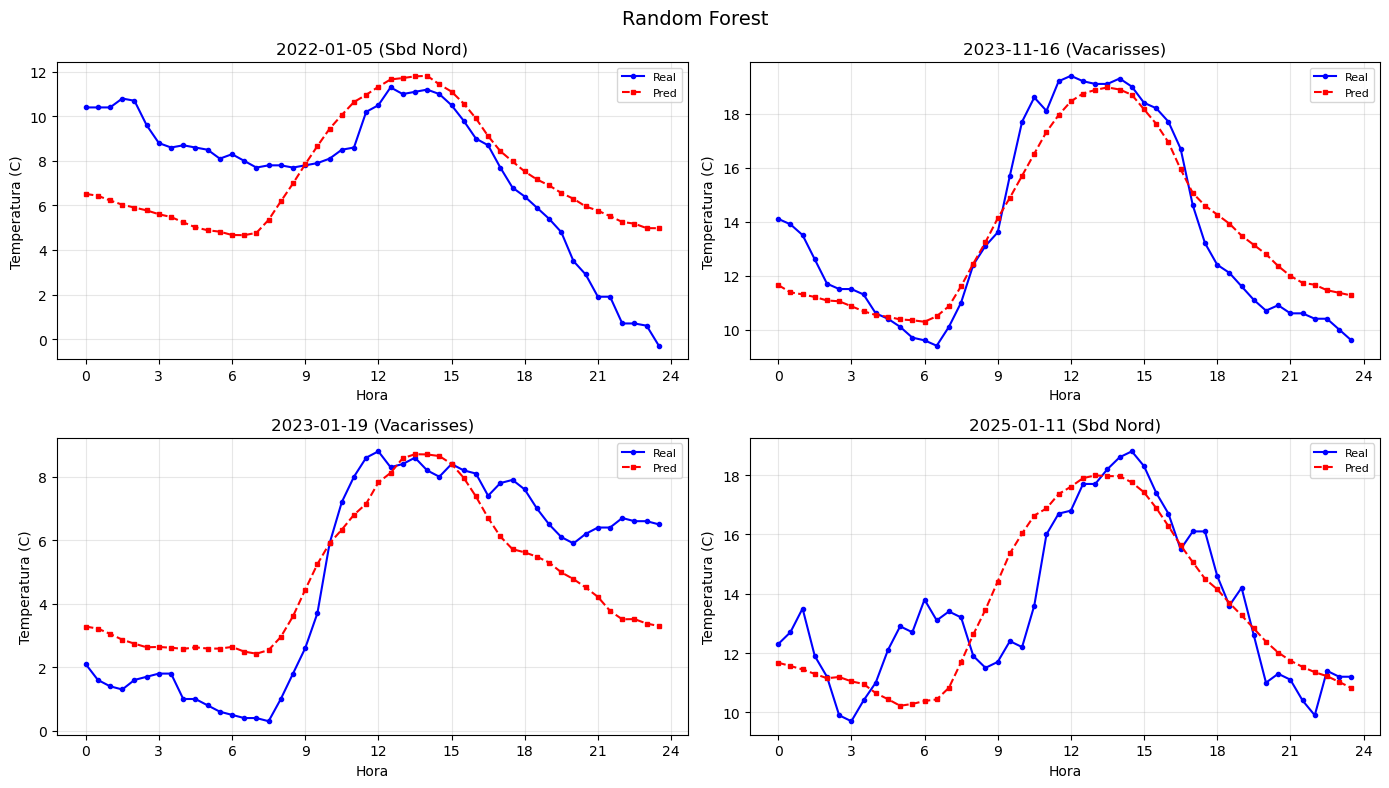

In [9]:
pipe_rf = Pipeline([('scaler',StandardScaler()),
    ('rf',RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
params_rf = {'rf__n_estimators':[100,200,300],'rf__max_depth':[10,20,None],
             'rf__min_samples_leaf':[1,2,5]}

print("GridSearch RF...")
gs_rf = GridSearchCV(pipe_rf, params_rf, cv=tscv,
                     scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
gs_rf.fit(X_tr, y_tr)
print(f"Best: {gs_rf.best_params_}")
yp_rf = gs_rf.predict(X_te)
res_rf = evaluate("Random Forest", y_te, yp_rf)
plot_curves(y_te, yp_rf, "Random Forest", dates=dates_te, stations=stations_te)

## 6. Model 4: XGBoost

In [10]:
if HAS_XGB:
    pipe_xgb = Pipeline([('scaler',StandardScaler()),
        ('xgb',MultiOutputRegressor(XGBRegressor(random_state=RANDOM_STATE, verbosity=0)))])
    params_xgb = {'xgb__estimator__n_estimators':[100,200],
                  'xgb__estimator__max_depth':[4,6,8],
                  'xgb__estimator__learning_rate':[0.05,0.1],
                  'xgb__estimator__subsample':[0.8,1.0]}
    print("GridSearch XGBoost...")
    gs_xgb = GridSearchCV(pipe_xgb, params_xgb, cv=tscv,
                          scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
    gs_xgb.fit(X_tr, y_tr)
    print(f"Best: {gs_xgb.best_params_}")
    yp_xgb = gs_xgb.predict(X_te)
    res_xgb = evaluate("XGBoost", y_te, yp_xgb)
    plot_curves(y_te, yp_xgb, "XGBoost", dates=dates_te, stations=stations_te)
else:
    print("XGBoost no disponible — s'omet")
    yp_xgb = None

XGBoost no disponible — s'omet


## 7. Model 5: MLP (Xarxa Neuronal)

GridSearch MLP...
Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best: {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (256, 128), 'mlp__learning_rate_init': 0.01}
MLP:
  RMSE: 1.177C  R2: 0.9719  Bias: -0.004C
  RMSE/slot: 1.168 +/- 0.148C


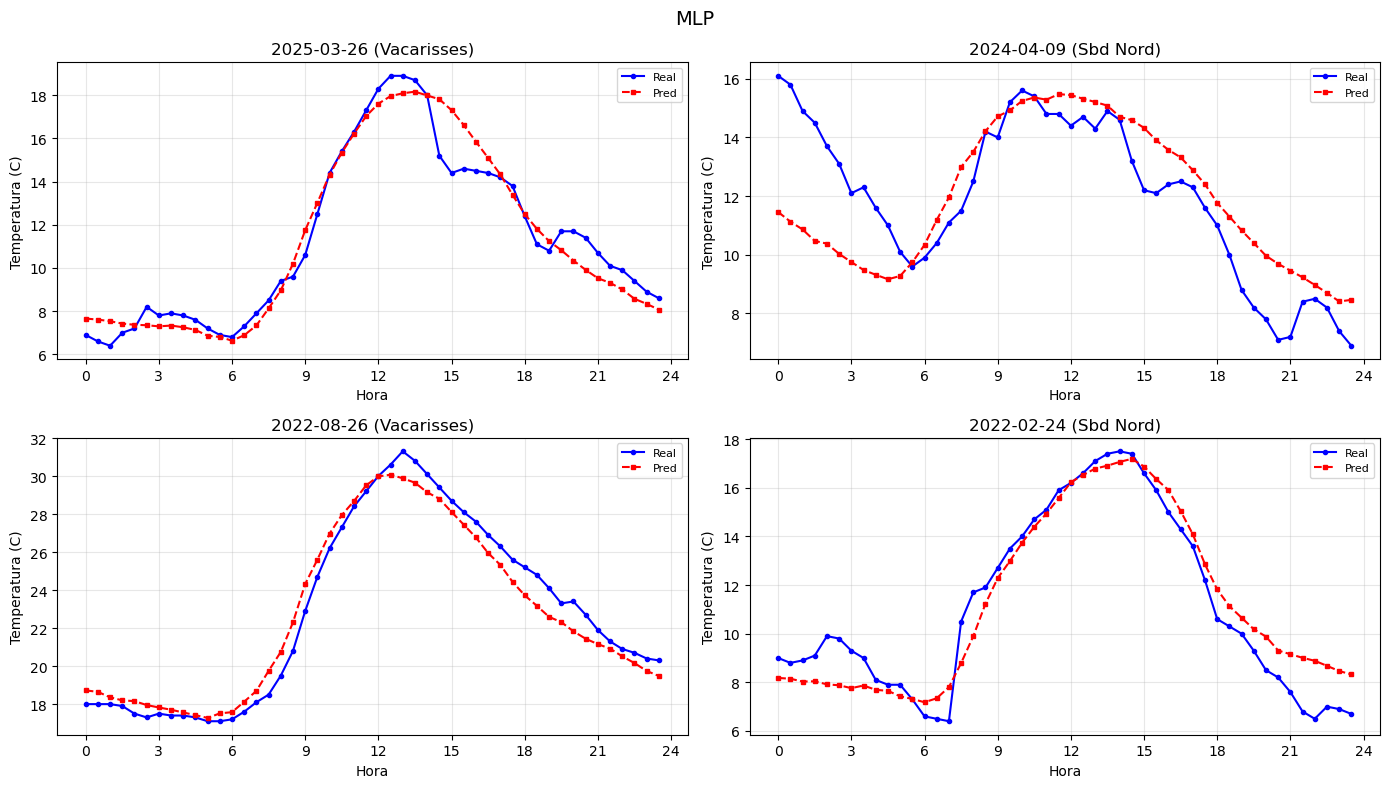

In [11]:
pipe_mlp = Pipeline([('scaler',StandardScaler()),
    ('mlp',MLPRegressor(random_state=RANDOM_STATE, early_stopping=True, max_iter=500))])
params_mlp = {'mlp__hidden_layer_sizes':[(64,32),(128,64),(128,64,32),(256,128)],
              'mlp__learning_rate_init':[0.001,0.01],'mlp__alpha':[0.0001,0.001]}

print("GridSearch MLP...")
gs_mlp = GridSearchCV(pipe_mlp, params_mlp, cv=tscv,
                      scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
gs_mlp.fit(X_tr, y_tr)
print(f"Best: {gs_mlp.best_params_}")
yp_mlp = gs_mlp.predict(X_te)
res_mlp = evaluate("MLP", y_te, yp_mlp)
plot_curves(y_te, yp_mlp, "MLP", dates=dates_te, stations=stations_te)

## 8. Comparacio de Models (Features Comunes)

In [12]:
results = [res_sin, res_knn, res_rf]
if HAS_XGB: results.append(res_xgb)
results.append(res_mlp)
results_table(results)

Model                RMSE (C)     R2         Bias (C)  
----------------------------------------------------
Sinusoidal (oracle)  1.468        0.9571     -0.000    
KNN                  1.454        0.9569     -0.130    
Random Forest        1.266        0.9676     -0.008    
MLP                  1.177        0.9719     -0.004    


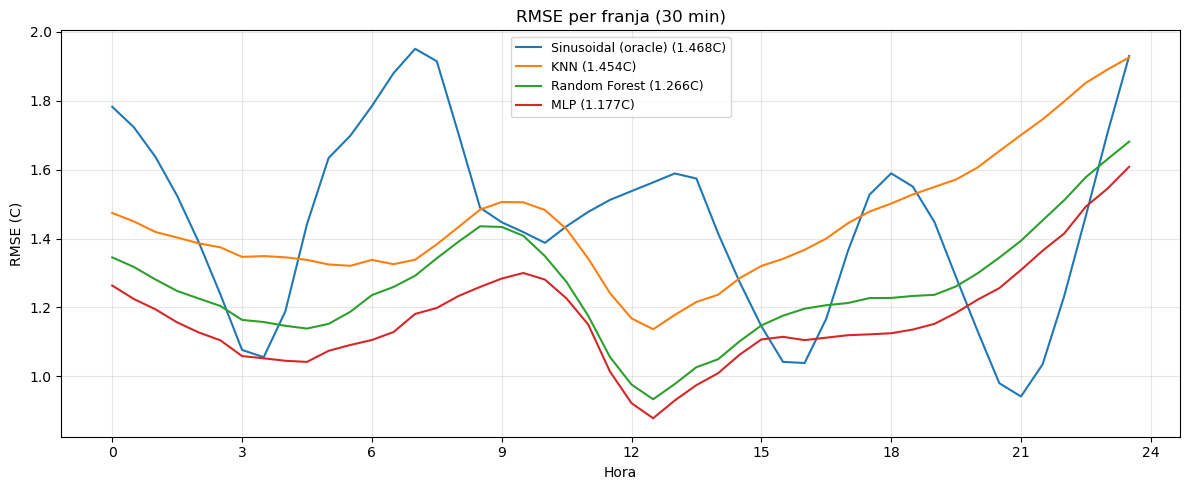

In [13]:
plot_rmse_slot(results)

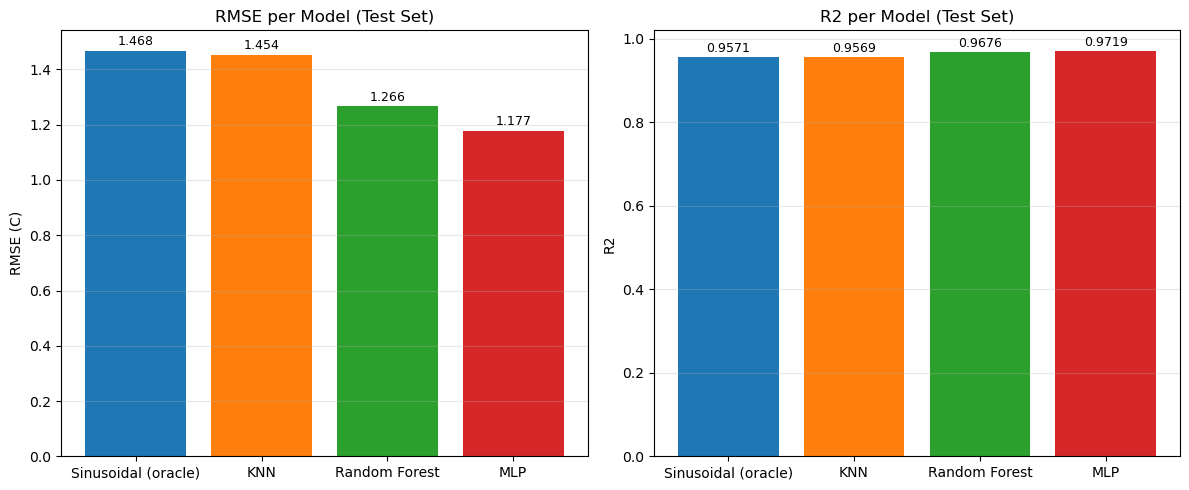

In [14]:
names = [r['name'] for r in results]
rmse_v = [r['rmse_global'] for r in results]
r2_v = [r['r2'] for r in results]
cols_b = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

fig, axes = plt.subplots(1,2,figsize=(12,5))
b1 = axes[0].bar(names, rmse_v, color=cols_b[:len(names)])
axes[0].set_ylabel("RMSE (C)"); axes[0].set_title("RMSE per Model (Test Set)")
axes[0].grid(axis='y', alpha=0.3)
for b,v in zip(b1, rmse_v):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=9)

b2 = axes[1].bar(names, r2_v, color=cols_b[:len(names)])
axes[1].set_ylabel("R2"); axes[1].set_title("R2 per Model (Test Set)")
axes[1].grid(axis='y', alpha=0.3)
for b,v in zip(b2, r2_v):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{v:.4f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

### 8.1 Error per estacio

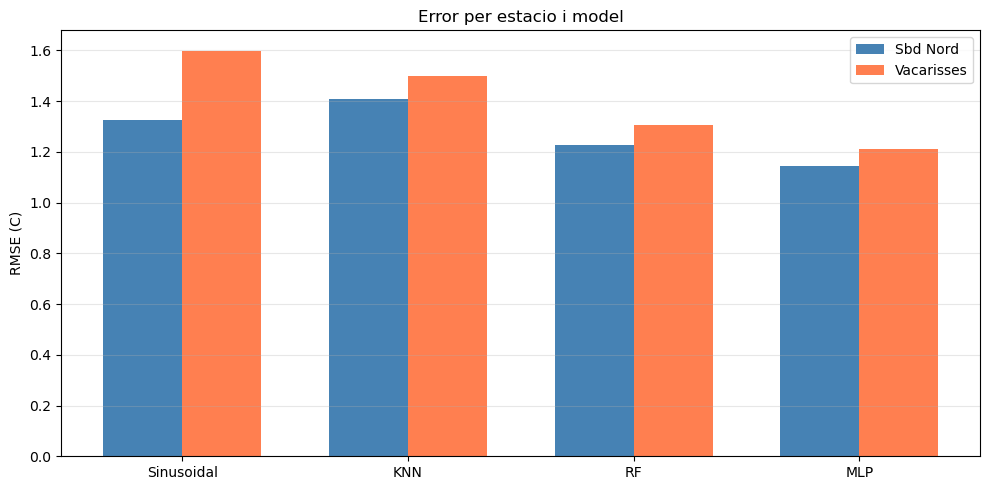

In [15]:
pred_dict = {'Sinusoidal':y_sin,'KNN':yp_knn,'RF':yp_rf}
if HAS_XGB: pred_dict['XGBoost'] = yp_xgb
pred_dict['MLP'] = yp_mlp

stat_errors = {}
for stn in ['Sbd Nord', 'Vacarisses']:
    m = stations_te == stn
    stat_errors[stn] = [np.sqrt(mean_squared_error(y_te[m], p[m])) for _,p in pred_dict.items()]

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(pred_dict)); w = 0.35
ax.bar(x-w/2, stat_errors['Sbd Nord'], w, label='Sbd Nord', color='steelblue')
ax.bar(x+w/2, stat_errors['Vacarisses'], w, label='Vacarisses', color='coral')
ax.set_xticks(x); ax.set_xticklabels(pred_dict.keys())
ax.set_ylabel("RMSE (C)"); ax.set_title("Error per estacio i model")
ax.legend(); ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

### 8.2 Error per estacio de l'any

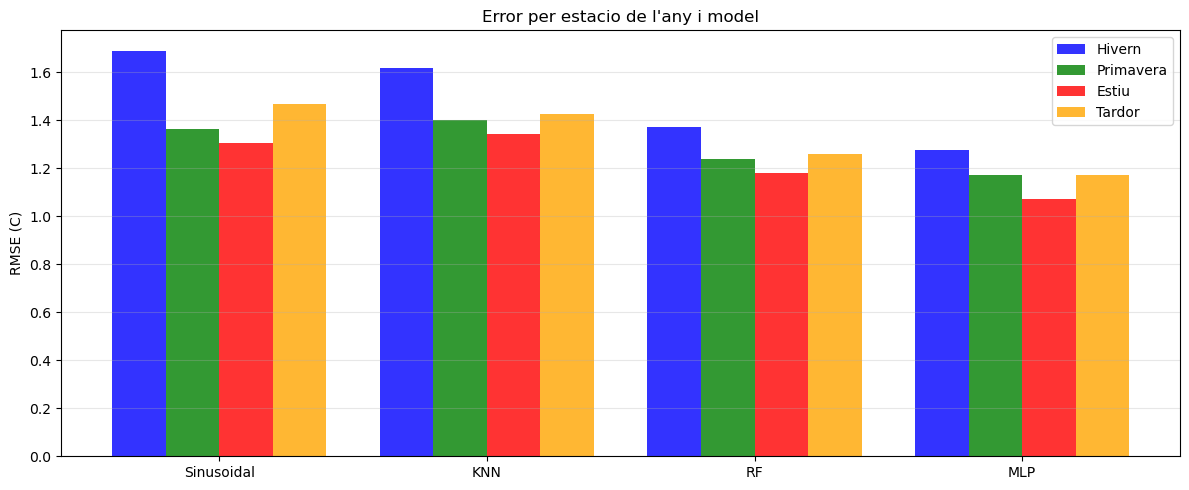

In [16]:
ssn_errors = {}
for ssn, ms in season_map.items():
    m = np.isin(months_te, ms)
    ssn_errors[ssn] = [np.sqrt(mean_squared_error(y_te[m], p[m])) for _,p in pred_dict.items()]

fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(pred_dict)); w = 0.2
for i, (ssn, c) in enumerate(zip(season_map.keys(), ['blue','green','red','orange'])):
    ax.bar(x+(i-1.5)*w, ssn_errors[ssn], w, label=ssn, color=c, alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(pred_dict.keys())
ax.set_ylabel("RMSE (C)"); ax.set_title("Error per estacio de l'any i model")
ax.legend(); ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

### 8.3 Importancia de features (Random Forest)

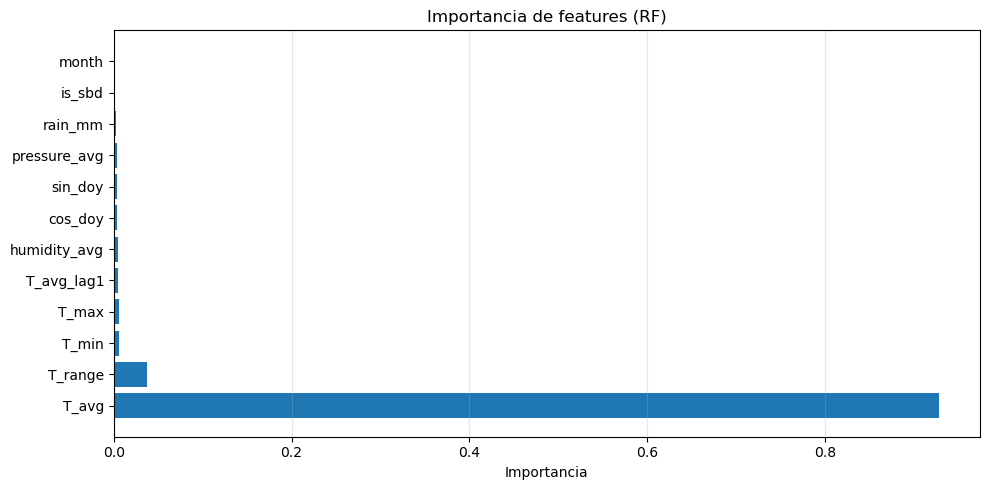

In [17]:
rf_best = gs_rf.best_estimator_.named_steps['rf']
imp = rf_best.feature_importances_
idx = np.argsort(imp)[::-1]
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(range(len(imp)), imp[idx])
ax.set_yticks(range(len(imp))); ax.set_yticklabels([feature_names[i] for i in idx])
ax.set_xlabel("Importancia"); ax.set_title("Importancia de features (RF)")
ax.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

## 9. Part B: Features Completes (Sbd Nord)
Carreguem les 15 features (incloent radiacio i vent) nomes per Sbd Nord,
i comparem amb els resultats de features comunes.

In [18]:
data_f = np.load("Cleaned Data/ml_data_full.npz", allow_pickle=False)
meta_f = pd.read_csv("Cleaned Data/ml_metadata_full.csv")

Xf, yf = data_f['X'], data_f['y']
fn_f = data_f['feature_names'].tolist()
yrs_f = data_f['years']; mns_f = data_f['months']
ts_f = pd.to_datetime(meta_f['date'])

print(f"Full features: {Xf.shape}")
print(f"Features: {fn_f}")

# Split
mask_tr_f = ts_f.dt.year <= 2020
Xf_tr, Xf_te = Xf[mask_tr_f], Xf[~mask_tr_f]
yf_tr, yf_te = yf[mask_tr_f], yf[~mask_tr_f]
tsf_tr = ts_f[mask_tr_f]; tsf_te = ts_f[~mask_tr_f]
print(f"Train: {Xf_tr.shape[0]}, Test: {Xf_te.shape[0]}")

Full features: (6367, 15)
Features: ['T_avg', 'T_max', 'T_min', 'humidity_avg', 'rain_mm', 'pressure_avg', 'radiation_avg', 'avg_wind_kmh', 'wind_dir', 'max_wind_kmh', 'T_range', 'T_avg_lag1', 'sin_doy', 'cos_doy', 'month']
Train: 4451, Test: 1916


### 9.1 Sinusoidal (Full features)

In [19]:
Tavg_f_te = Xf_te[:, fn_f.index('T_avg')]
y_sin_f = fit_sin_per_day(yf_te, Tavg_f_te)
res_sin_f = evaluate("Sinusoidal (full)", yf_te, y_sin_f, verbose=True)

Sinusoidal (full):
  RMSE: 1.325C  R2: 0.9612  Bias: -0.000C
  RMSE/slot: 1.295 +/- 0.279C


#### 9.1.1 Sinusoidal 2-stage (Mac version)

In [20]:
def fit_sin_params(y_day, Tavg_day):
    t_h = np.arange(HOURS_PER_DAY) / 2
    A = np.full(len(y_day), np.nan)
    phi = np.full(len(y_day), np.nan)
    for i in range(len(y_day)):
        try:
            popt, _ = curve_fit(
                lambda x, a, p: Tavg_day[i] + a * np.sin(2*np.pi*x/24 + p),
                t_h, y_day[i], p0=[(y_day[i].max()-y_day[i].min())/2, 2], maxfev=5000)
            A[i], phi[i] = popt[0], popt[1]
        except:
            A[i] = (y_day[i].max() - y_day[i].min()) / 2
            phi[i] = -np.pi/2 + 3.5
    return A, phi

Tavg_f_tr = Xf_tr[:, fn_f.index('T_avg')]
Tavg_f_te = Xf_te[:, fn_f.index('T_avg')]
A_tr_f, phi_tr_f = fit_sin_params(yf_tr, Tavg_f_tr)

rf_sin2 = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
rf_sin2.fit(Xf_tr, np.column_stack([A_tr_f, phi_tr_f]))
A_pr_f, phi_pr_f = rf_sin2.predict(Xf_te)[:,0], rf_sin2.predict(Xf_te)[:,1]

y_sin2_f = np.zeros_like(yf_te)
for i in range(len(yf_te)):
    y_sin2_f[i] = Tavg_f_te[i] + A_pr_f[i] * np.sin(2*np.pi*t/24 + phi_pr_f[i])
res_sin2_f = evaluate("Sinusoidal 2-stage (full)", yf_te, y_sin2_f, verbose=True)

Sinusoidal 2-stage (full):
  RMSE: 1.923C  R2: 0.9193  Bias: -0.000C
  RMSE/slot: 1.870 +/- 0.447C


### 9.2 Random Forest (Full features)

In [21]:
print("GridSearch RF (full features)...")
gs_rf_f = GridSearchCV(Pipeline([('scaler',StandardScaler()),
    ('rf',RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=-1))]),
    {'rf__n_estimators':[100,200],'rf__max_depth':[10,20,None],
     'rf__min_samples_leaf':[1,2,5]},
    cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
gs_rf_f.fit(Xf_tr, yf_tr)
print(f"Best: {gs_rf_f.best_params_}")
yp_rf_f = gs_rf_f.predict(Xf_te)
res_rf_f = evaluate("Random Forest (full)", yf_te, yp_rf_f)

GridSearch RF (full features)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


Best: {'rf__max_depth': 20, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 200}
Random Forest (full):
  RMSE: 1.193C  R2: 0.9681  Bias: -0.010C
  RMSE/slot: 1.184 +/- 0.152C


### 9.3 XGBoost (Full features)

In [22]:
if HAS_XGB:
    print("GridSearch XGBoost (full features)...")
    gs_xgb_f = GridSearchCV(Pipeline([('scaler',StandardScaler()),
        ('xgb',MultiOutputRegressor(XGBRegressor(random_state=RANDOM_STATE,verbosity=0)))]),
        {'xgb__estimator__n_estimators':[100,200],'xgb__estimator__max_depth':[4,6,8],
         'xgb__estimator__learning_rate':[0.05,0.1],'xgb__estimator__subsample':[0.8,1.0]},
        cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
    gs_xgb_f.fit(Xf_tr, yf_tr)
    print(f"Best: {gs_xgb_f.best_params_}")
    yp_xgb_f = gs_xgb_f.predict(Xf_te)
    res_xgb_f = evaluate("XGBoost (full)", yf_te, yp_xgb_f)
else:
    print("XGBoost no disponible")
    yp_xgb_f = None

XGBoost no disponible


### 9.4 MLP (Full features)

In [23]:
print("GridSearch MLP (full features)...")
gs_mlp_f = GridSearchCV(Pipeline([('scaler',StandardScaler()),
    ('mlp',MLPRegressor(random_state=RANDOM_STATE,early_stopping=True,max_iter=500))]),
    {'mlp__hidden_layer_sizes':[(64,32),(128,64),(128,64,32)],
     'mlp__learning_rate_init':[0.001,0.01],'mlp__alpha':[0.0001,0.001]},
    cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
gs_mlp_f.fit(Xf_tr, yf_tr)
print(f"Best: {gs_mlp_f.best_params_}")
yp_mlp_f = gs_mlp_f.predict(Xf_te)
res_mlp_f = evaluate("MLP (full)", yf_te, yp_mlp_f)

GridSearch MLP (full features)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.01}
MLP (full):
  RMSE: 1.162C  R2: 0.9698  Bias: 0.080C
  RMSE/slot: 1.153 +/- 0.146C


### 9.5 Comparacio: Common vs Full Features (Sbd Nord)

In [24]:
# Get Sbd Nord subset from common-features predictions
m_sbd = stations_te == 'Sbd Nord'
yr_te_sbd = ts_te[m_sbd]

# Filter common predictions to just Sbd Nord test years
# (full features uses only Sbd Nord, so the test sets may differ slightly)
# Align by matching predictions that overlap
# Simple approach: compare common-feature model on Sbd Nord subset
y_sin_sbd = y_sin[m_sbd]
yp_rf_sbd = yp_rf[m_sbd]
yp_mlp_sbd = yp_mlp[m_sbd]

print("=== Sbd Nord Test Set ===")
print(f"{'Model':<25} {'RMSE (C)':<12} {'R2':<10}")
print("-"*47)
print(f"{'Sinusoidal (common)':<25} {np.sqrt(mean_squared_error(y_te[m_sbd], y_sin_sbd)):<12.3f} {r2_score(y_te[m_sbd], y_sin_sbd):<10.4f}")
print(f"{'Sinusoidal (full)':<25} {res_sin_f['rmse_global']:<12.3f} {res_sin_f['r2']:<10.4f}")
print(f"{'Sin 2-stage (full)':<25} {res_sin2_f['rmse_global']:<12.3f} {res_sin2_f['r2']:<10.4f}")
print(f"{'RF (common)':<25} {np.sqrt(mean_squared_error(y_te[m_sbd], yp_rf_sbd)):<12.3f} {r2_score(y_te[m_sbd], yp_rf_sbd):<10.4f}")
print(f"{'RF (full)':<25} {res_rf_f['rmse_global']:<12.3f} {res_rf_f['r2']:<10.4f}")
print(f"{'MLP (common)':<25} {np.sqrt(mean_squared_error(y_te[m_sbd], yp_mlp_sbd)):<12.3f} {r2_score(y_te[m_sbd], yp_mlp_sbd):<10.4f}")
print(f"{'MLP (full)':<25} {res_mlp_f['rmse_global']:<12.3f} {res_mlp_f['r2']:<10.4f}")

=== Sbd Nord Test Set ===
Model                     RMSE (C)     R2        
-----------------------------------------------
Sinusoidal (common)       1.325        0.9612    
Sinusoidal (full)         1.325        0.9612    
Sin 2-stage (full)        1.923        0.9193    
RF (common)               1.227        0.9666    
RF (full)                 1.193        0.9681    
MLP (common)              1.145        0.9708    
MLP (full)                1.162        0.9698    


### 9.6 Perfil d'error horari (Full vs Common, Sbd Nord)

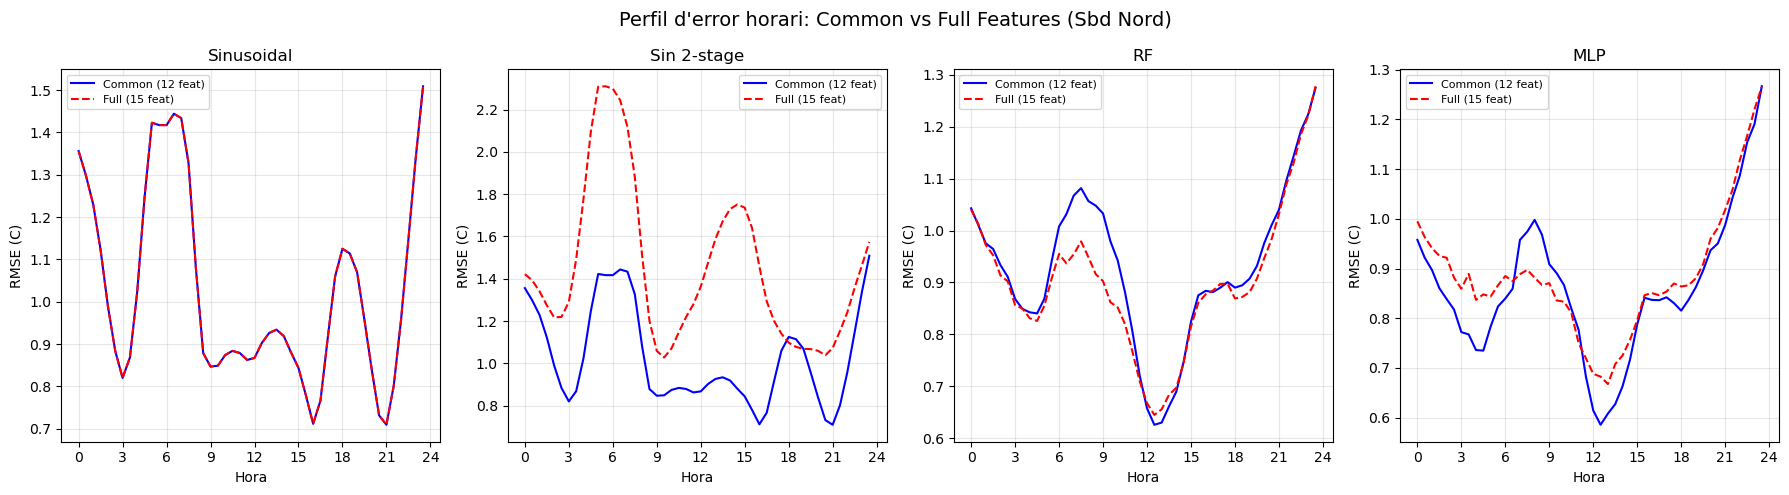

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, name, (yc, yf) in zip(axes,
    ['Sinusoidal', 'Sin 2-stage', 'RF', 'MLP'],
    [(y_sin_sbd, y_sin_f), (y_sin_sbd, y_sin2_f), (yp_rf_sbd, yp_rf_f), (yp_mlp_sbd, yp_mlp_f)]):
    err_c = np.sqrt((y_te[m_sbd] - yc) ** 2).mean(0)
    err_f = np.sqrt((yf_te - yf) ** 2).mean(0)
    ax.plot(hours, err_c, 'b-', label='Common (12 feat)', lw=1.5)
    ax.plot(hours, err_f, 'r--', label='Full (15 feat)', lw=1.5)
    ax.set_title(name); ax.set_xlabel("Hora"); ax.set_ylabel("RMSE (C)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xticks(range(0,25,3))
fig.suptitle("Perfil d'error horari: Common vs Full Features (Sbd Nord)", fontsize=14)
plt.tight_layout(); plt.show()

## 10. Part C: Analisi de Residuals

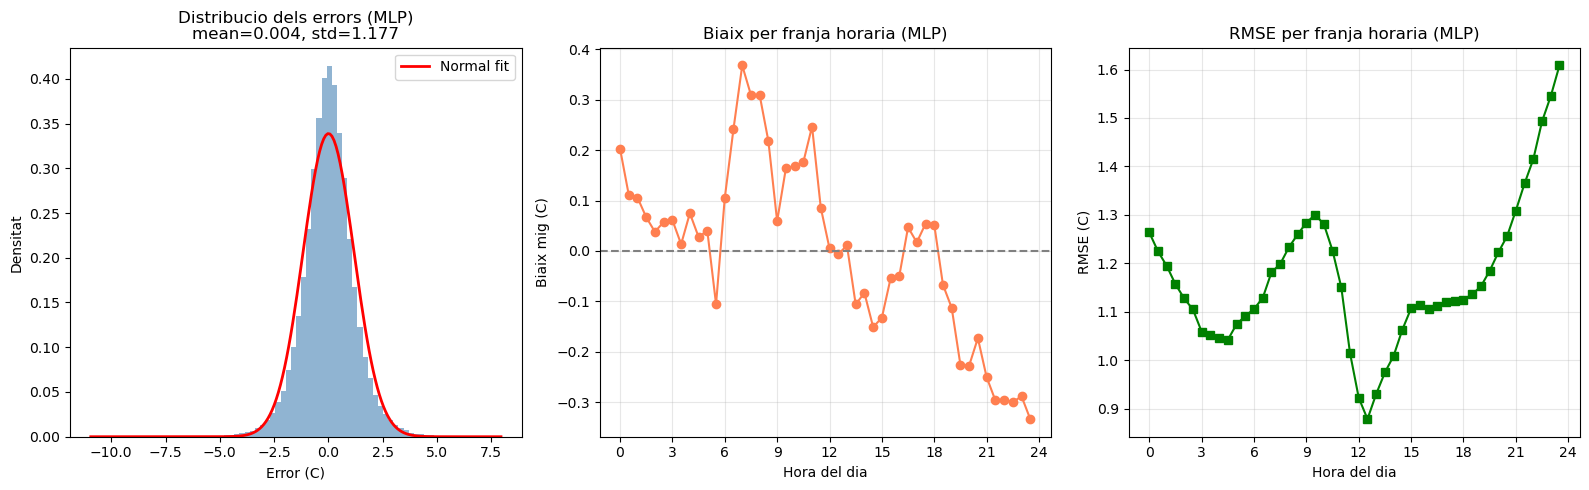

In [26]:
# Residuals del millor model (MLP amb features comunes)
residuals = y_te - yp_mlp

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribucio
axes[0].hist(residuals.ravel(), bins=80, density=True, alpha=0.6, color='steelblue')
x_grid = np.linspace(residuals.min(), residuals.max(), 200)
axes[0].plot(x_grid, norm.pdf(x_grid, residuals.mean(), residuals.std()),
             'r-', lw=2, label='Normal fit')
axes[0].set_xlabel("Error (C)"); axes[0].set_ylabel("Densitat")
axes[0].set_title("Distribucio dels errors (MLP)\nmean={:.3f}, std={:.3f}".format(residuals.mean(), residuals.std()))
axes[0].legend()

# Error per hora (biaix)
bias_hourly = residuals.mean(axis=0)
axes[1].plot(hours, bias_hourly, 'o-', color='coral')
axes[1].axhline(0, color='gray', ls='--')
axes[1].set_xlabel("Hora del dia"); axes[1].set_ylabel("Biaix mig (C)")
axes[1].set_title("Biaix per franja horaria (MLP)")
axes[1].grid(alpha=0.3); axes[1].set_xticks(range(0,25,3))

# RMSE per hora (de MLP)
rmse_hourly = np.sqrt((residuals**2).mean(axis=0))
axes[2].plot(hours, rmse_hourly, 's-', color='green')
axes[2].set_xlabel("Hora del dia"); axes[2].set_ylabel("RMSE (C)")
axes[2].set_title("RMSE per franja horaria (MLP)")
axes[2].grid(alpha=0.3); axes[2].set_xticks(range(0,25,3))

plt.tight_layout(); plt.show()

## 11. Conclusions

**Millor model (features comunes, ambdues estacions):** (completar despres d'executar)
**Millor model (features completes, Sbd Nord):** (completar)
**Millora en afegir vent + radiacio:** (completar)
**Error per estacio de l'any:** (completar)
**Proximes passes:** (completar)